In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import imageio.v2 as imageio

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate

In [58]:
project_path = os.path.join(os.getcwd(), 'data')
image_path = os.path.join(project_path, 'leftImg8bit_trainvaltest', 'leftImg8bit', 'train')
mask_path = os.path.join(project_path, 'gtFine', 'train')

In [59]:

print("Current working directory:", os.getcwd())
print("Image path:", image_path)
print("Mask path:", mask_path)
print("Image path exists:", os.path.exists(image_path))
print("Mask path exists:", os.path.exists(mask_path))

Current working directory: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation
Image path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train
Mask path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train
Image path exists: True
Mask path exists: True


In [60]:
image_list = []
mask_list = []

In [61]:
# Iterate through city subdirectories
for city in os.listdir(image_path):
    city_image_path = os.path.join(image_path, city)
    city_mask_path = os.path.join(mask_path, city)
    
    if os.path.isdir(city_image_path) and not city.startswith('.'):
        image_list.extend([os.path.join(city_image_path, img) for img in os.listdir(city_image_path) if img.endswith('_leftImg8bit.png')])
        mask_list.extend([os.path.join(city_mask_path, msk) for msk in os.listdir(city_mask_path) if msk.endswith('_gtFine_labelIds.png')])

In [62]:
image_list.sort()
mask_list.sort()

In [63]:
image_list = image_list[:1500]
mask_list = mask_list[:1500]

split_index = int(0.8 * len(image_list))

train_images = image_list[:split_index]
train_masks = mask_list[:split_index]

val_images = image_list[split_index:]
val_masks = mask_list[split_index:]

print("Total images:", len(image_list))
print("Total masks:", len(mask_list))
print("Train images:", len(train_images))
print("Train masks:", len(train_masks))
print("Val images:", len(val_images))
print("Val masks:", len(val_masks))
print("First train image:", train_images[0])
print("First train mask:", train_masks[0])

Total images: 1500
Total masks: 1500
Train images: 1200
Train masks: 1200
Val images: 300
Val masks: 300
First train image: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
First train mask: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png


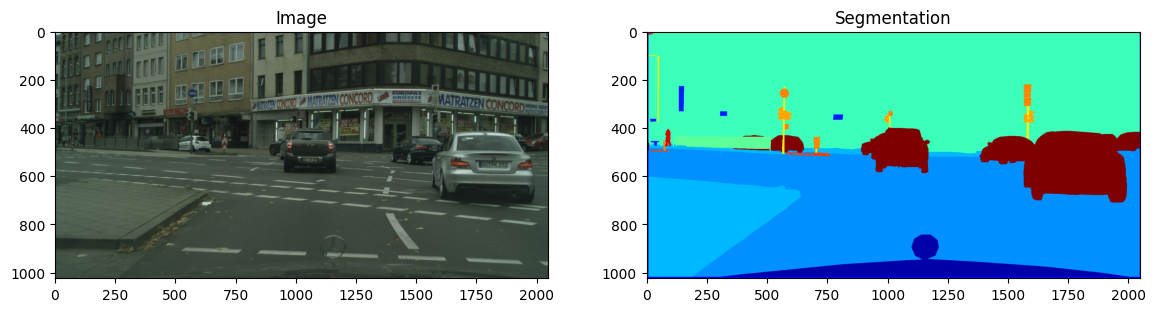

In [64]:
N = 3
img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])
#mask = np.array([max(mask[i, j]) for i in range(mask.shape[0]) for j in range(mask.shape[1])]).reshape(img.shape[0], img.shape[1])

fig, arr = plt.subplots(1, 2, figsize=(14, 10))
arr[0].imshow(img)
arr[0].set_title('Image')
arr[1].imshow(mask, cmap='jet')
arr[1].set_title('Segmentation')
plt.show()

In [65]:
image_list_ds = tf.data.Dataset.list_files(image_list, shuffle=False)
mask_list_ds = tf.data.Dataset.list_files(mask_list, shuffle=False)

for path in zip(image_list_ds.take(3), mask_list_ds.take(3)):
    print(path)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000001_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000001_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000002_000019_leftImg8bit.png'>, <tf.

In [66]:
train_image_filenames = tf.constant(train_images)
train_mask_filenames = tf.constant(train_masks)

val_image_filenames = tf.constant(val_images)
val_mask_filenames = tf.constant(val_masks)

train_raw_dataset = tf.data.Dataset.from_tensor_slices((train_image_filenames, train_mask_filenames))
val_raw_dataset = tf.data.Dataset.from_tensor_slices((val_image_filenames, val_mask_filenames))

for image, mask in train_raw_dataset.take(1):
    print("Train sample:")
    print(image)
    print(mask)

for image, mask in val_raw_dataset.take(1):
    print("Validation sample:")
    print(image)
    print(mask)

Train sample:
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png', shape=(), dtype=string)
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png', shape=(), dtype=string)
Validation sample:
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/hamburg/hamburg_000000_029676_leftImg8bit.png', shape=(), dtype=string)
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/hamburg/hamburg_000000_029676_gtFine_labelIds.png', shape=(), dtype=string)


In [67]:
def process_path(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    return img, mask

In [68]:
def preprocess(image, mask):
    input_image = tf.image.resize(image, (96, 128), method='nearest')
    input_mask = tf.image.resize(mask, (96, 128), method='nearest')
    return input_image, input_mask

In [69]:
train_image_ds = train_raw_dataset.map(process_path)
train_processed_ds = train_image_ds.map(preprocess)

val_image_ds = val_raw_dataset.map(process_path)
val_processed_ds = val_image_ds.map(preprocess)

In [70]:
def conv_block(inputs = None, n_filters = 32, dropout_prob = 0, max_pooling = True):
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (inputs)
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (conv)
    
    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)
    
    if max_pooling:
        next_layer = MaxPooling2D(2, strides=2)(conv)
    else:
        next_layer = conv
    
    skip_connection = conv

    return next_layer, skip_connection


In [71]:
def upsampling_block(expansive_output, contractive_output, n_filters = 32):
    up = Conv2DTranspose(n_filters, 3, strides=2, padding='same') (expansive_output)
    merge = concatenate([up, contractive_output], axis=3)

    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(merge)
    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(conv)

    return conv


In [72]:
def unet_model(input_size = (96, 128, 3), n_filters = 32, n_classes = 34):

    inputs = Input(input_size)

    cblock1 = conv_block(inputs= inputs, n_filters= n_filters*1)
    cblock2 = conv_block(inputs= cblock1[0], n_filters= n_filters*2)
    cblock3 = conv_block(inputs= cblock2[0], n_filters= n_filters*4)
    cblock4 = conv_block(inputs= cblock3[0], n_filters= n_filters*8, dropout_prob=0.3)
    cblock5 = conv_block(inputs= cblock4[0], n_filters= n_filters*16, dropout_prob=0.3, max_pooling=False)

    ublock6 = upsampling_block(cblock5[0], cblock4[1], n_filters= n_filters*8)
    ublock7 = upsampling_block(ublock6, cblock3[1], n_filters= n_filters*4)
    ublock8 = upsampling_block(ublock7, cblock2[1], n_filters= n_filters*2)
    ublock9 = upsampling_block(ublock8, cblock1[1], n_filters= n_filters*1)

    conv9 = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(ublock9)
    conv10 = Conv2D(n_classes, 1, padding='same')(conv9)

    model = tf.keras.Model(inputs = inputs, outputs = conv10)

    return model



In [73]:
# set model dimensions

img_height = 96
img_width = 128
num_channels = 3

unet = unet_model((img_height, img_width, num_channels))

In [74]:
unet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 96, 128,   │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 96, 128,   │      9,248 │ conv2d_40[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 48, 64,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 48, 64,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 48, 64,    │     36,928 │ conv2d_42[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 24, 32,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 24, 32,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 24, 32,    │    147,584 │ conv2d_44[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 12, 16,    │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 12, 16,    │    295,168 │ max_pooling2d_10… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 12, 16,    │    590,080 │ conv2d_46[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 12, 16,    │          0 │ conv2d_47[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 6, 8, 256) │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 6, 8, 512) │  2,359,808 │ conv2d_48[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 12, 16,    │  1,179,904 │ dropout_5[0][0] 

 Total params: 8,640,834 (32.96 MB)

 Trainable params: 8,640,834 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
	
unet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [76]:
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

Raw train mask shape: (1024, 2048, 1)


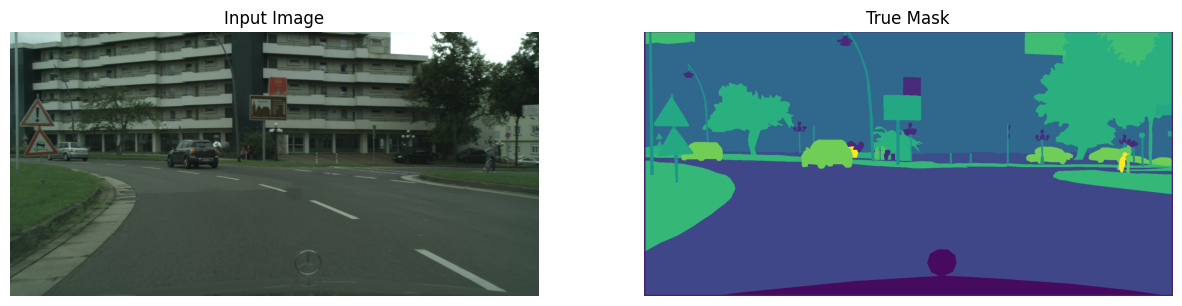

In [77]:
for image, mask in train_image_ds.take(1):
    sample_image, sample_mask = image, mask
    print("Raw train mask shape:", mask.shape)

display([sample_image, sample_mask])

Processed train mask shape: (96, 128, 1)


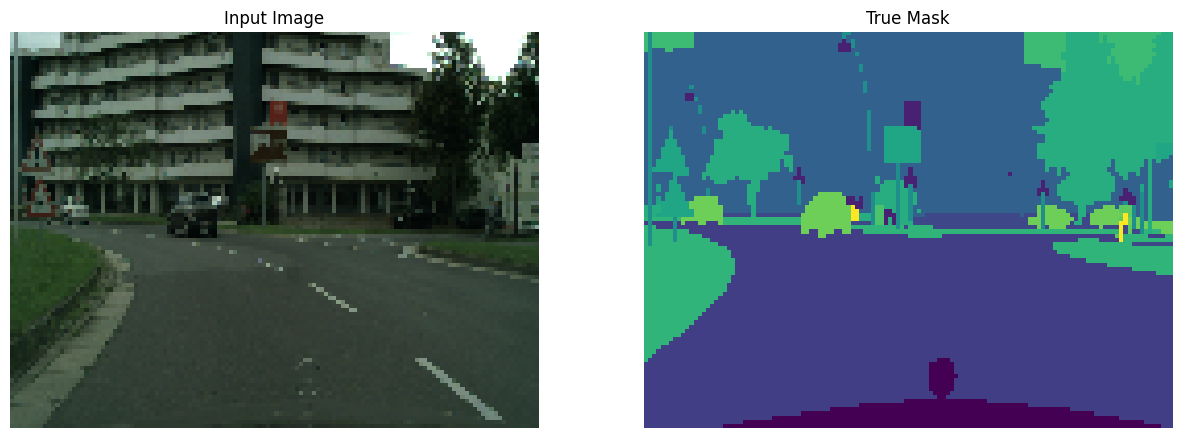

In [78]:
for image, mask in train_processed_ds.take(1):
    sample_image, sample_mask = image, mask
    print("Processed train mask shape:", mask.shape)

display([sample_image, sample_mask])

In [79]:
EPOCHS = 15
BUFFER_SIZE = 500
BATCH_SIZE = 16

train_dataset = train_processed_ds.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
val_dataset = val_processed_ds.batch(BATCH_SIZE)

print(train_processed_ds.element_spec)
print(val_processed_ds.element_spec)

model_history = unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 370ms/step - accuracy: 0.4534 - loss: 2.1450 - val_accuracy: 0.5440 - val_loss: 1.7590
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 372ms/step - accuracy: 0.6569 - loss: 1.2180 - val_accuracy: 0.5985 - val_loss: 1.4479
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 384ms/step - accuracy: 0.6905 - loss: 1.0707 - val_accuracy: 0.6314 - val_loss: 1.4093
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 387ms/step - accuracy: 0.7222 - loss: 0.9766 - val_accuracy: 0.6563 - val_loss: 1.2122
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 393ms/step - accuracy: 0.7587 - loss: 0.8896 - val_accuracy: 0.6532 - val_loss: 1.2375
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 394ms/step - accuracy: 0.7665 - loss: 0.8602 - val_accuracy: 0.7006 - v

In [80]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

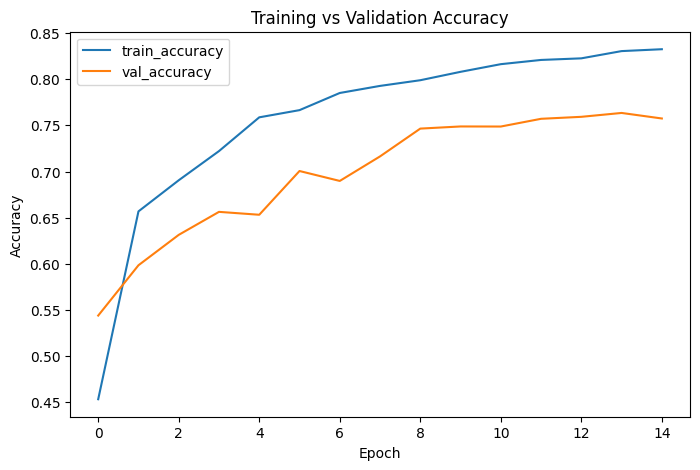

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(model_history.history["accuracy"], label="train_accuracy")
plt.plot(model_history.history["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

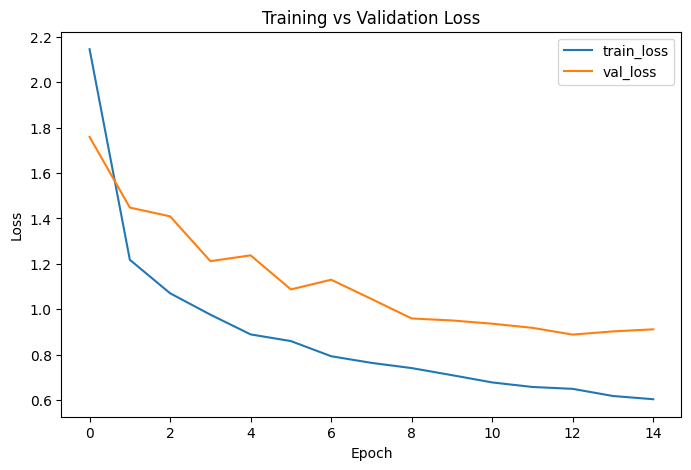

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(model_history.history["loss"], label="train_loss")
plt.plot(model_history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [83]:
def show_predictions(dataset=None, num=1):

    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = unet.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
             create_mask(unet.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


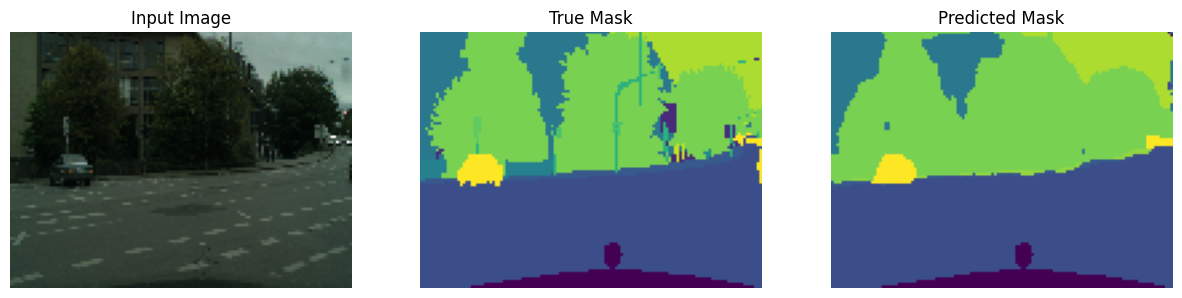

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


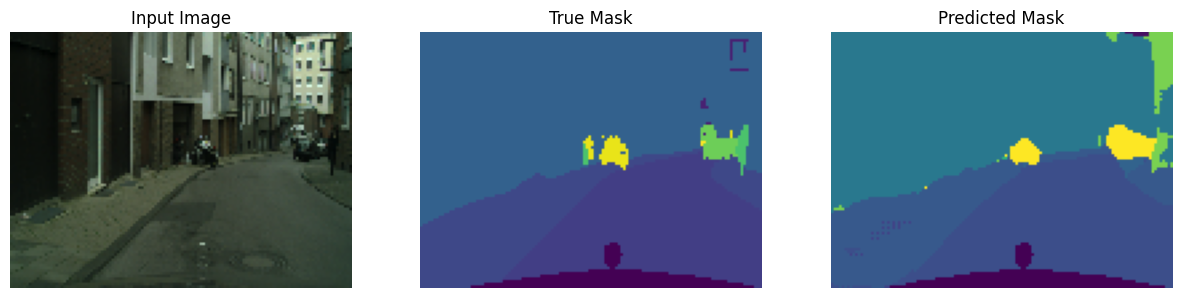

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


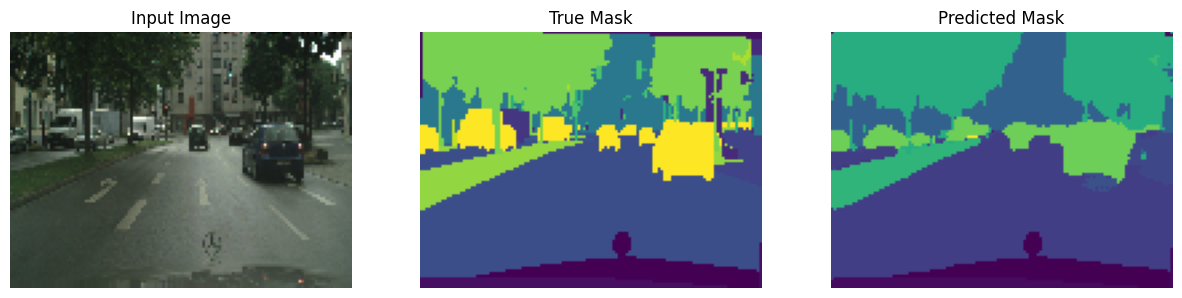

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


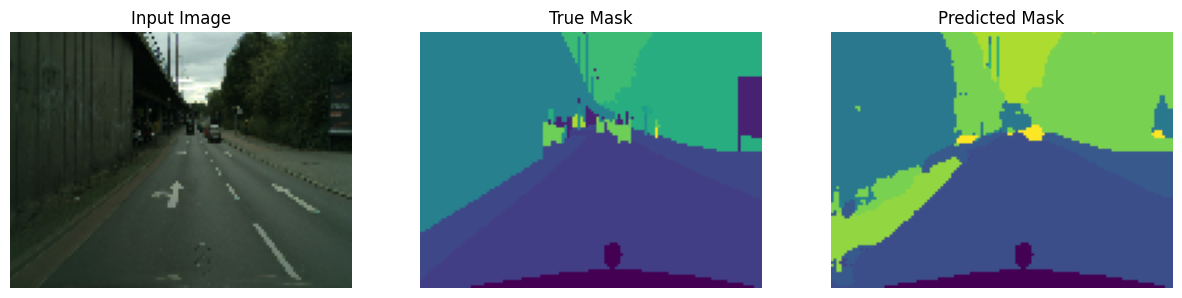

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


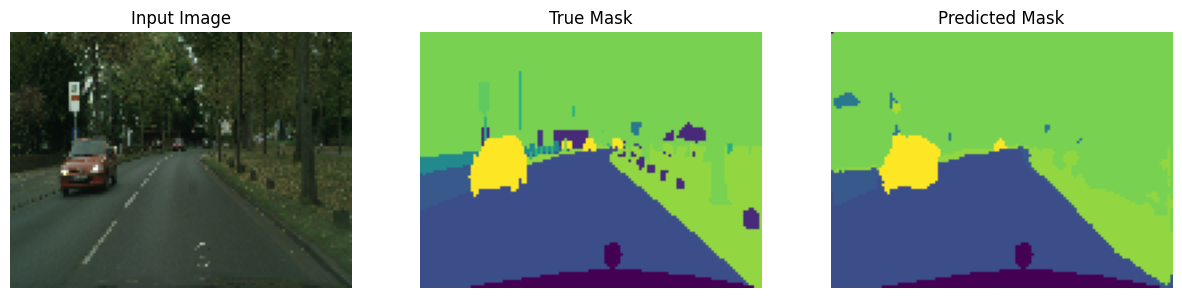

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


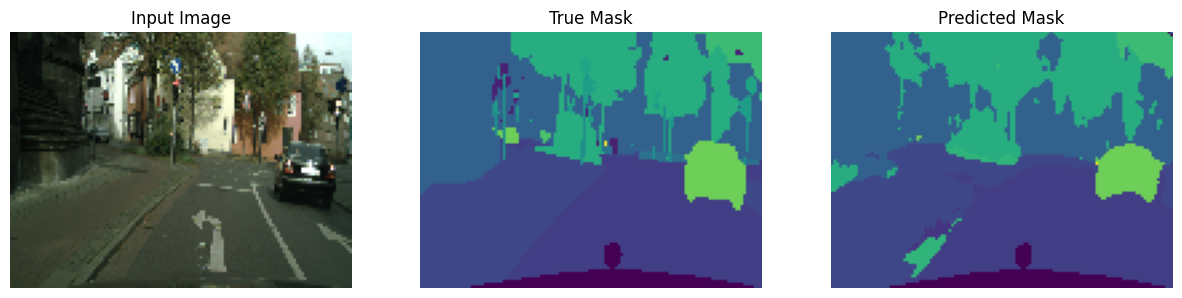

In [84]:
show_predictions(train_dataset, 6)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


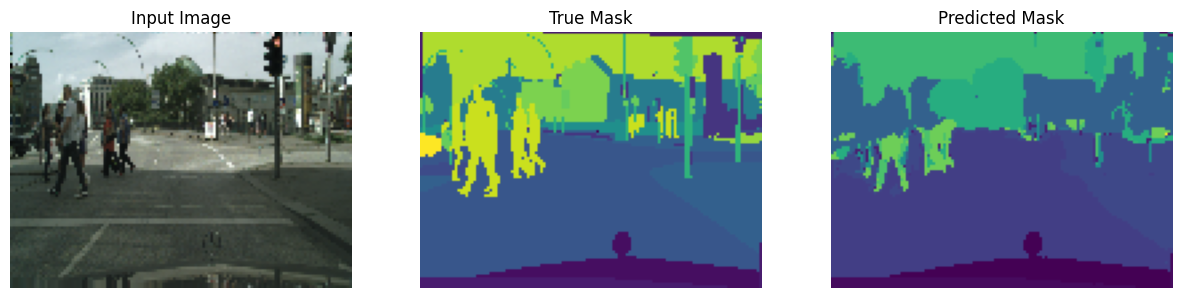

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


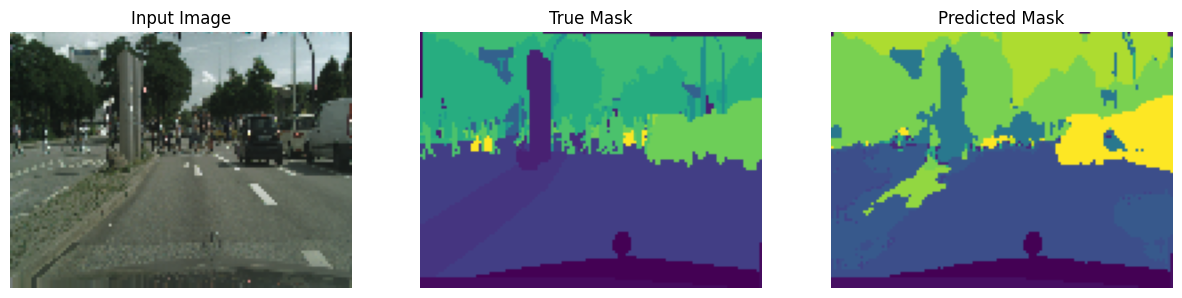

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


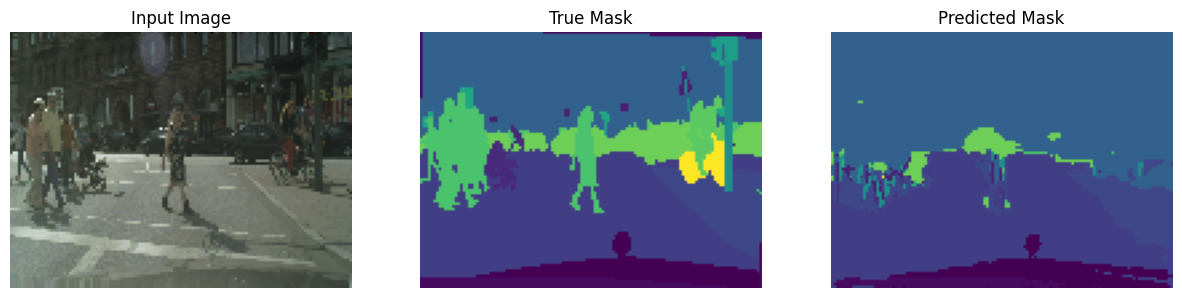

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


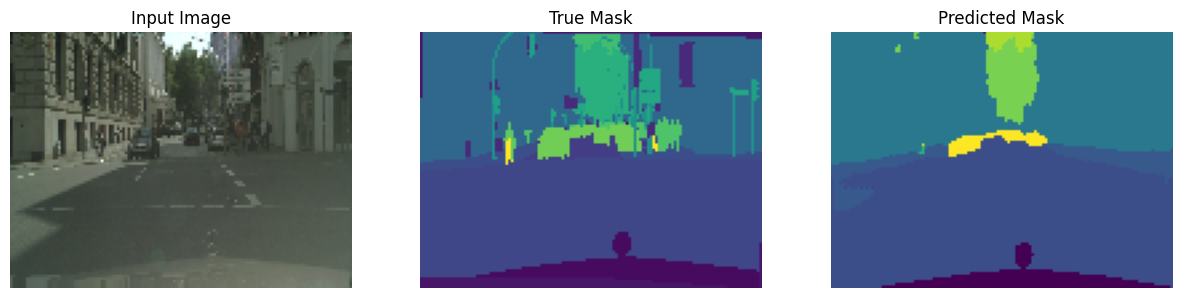

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


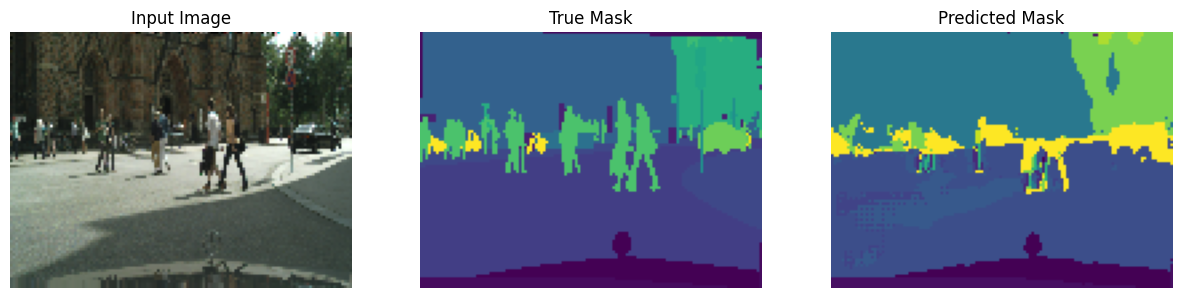

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


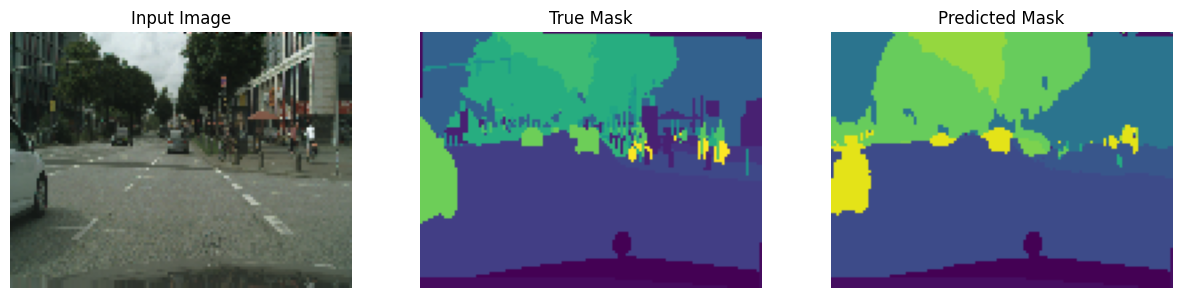

In [85]:
show_predictions(val_dataset, 6)

In [86]:
import os

# Create folder to store outputs
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

def save_predictions(dataset, num=5):
    for i, (image, mask) in enumerate(dataset.take(num)):
        pred_mask = unet.predict(image)

        pred_mask = tf.argmax(pred_mask, axis=-1)
        pred_mask = pred_mask[..., tf.newaxis]

        # Convert to displayable images
        input_img = tf.keras.preprocessing.image.array_to_img(image[0])
        true_mask = tf.keras.preprocessing.image.array_to_img(mask[0])
        predicted_mask = tf.keras.preprocessing.image.array_to_img(pred_mask[0])

        # Save images
        input_img.save(f"{output_dir}/input_{i}.png")
        true_mask.save(f"{output_dir}/true_{i}.png")
        predicted_mask.save(f"{output_dir}/pred_{i}.png")

# Run it
save_predictions(val_dataset, 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
